# Cancer Subtype Classification Using Gene Expression Data

**Author:** Sneha Galimotu

## Objective
To classify different cancer subtypes using gene expression data and machine learning algorithms.

## Workflow
1. Load dataset
2. Explore dataset
3. Data preprocessing
4. Feature selection
5. Model training
6. Model evaluation
7. Identify important genes
8. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
file_path = "Data/GSE45827_series_matrix.txt"

with open(file_path, "r") as file:
    lines = file.readlines()

print("Total number of lines:", len(lines))

Total number of lines: 29943


In [3]:
for i in range(20):
    print(lines[i])

!Series_title	"Expression data from Breast cancer subtypes"

!Series_geo_accession	"GSE45827"

!Series_status	"Public on Mar 24 2016"

!Series_submission_date	"Apr 05 2013"

!Series_last_update_date	"Mar 25 2019"

!Series_pubmed_id	"27006338"

!Series_summary	"Expression data from Breast cancer subtypes"

!Series_overall_design	"In a cohort study of primary invasive breast cancer (41 TN, 30 HER2, 29 Luminal A and 30 Luminal B) as well as 11 normal tissues samples and 14 cell lines , we obtained a tumor specimen at surgery before any patient treatment. Total RNA was extracted from all samples and the whole transcriptome was quantified with Affymetrix U133 Plus 2.0 Chips."

!Series_type	"Expression profiling by array"

!Series_contributor	"Tina,,Gruosso"

!Series_contributor	"Yann,,Kieffer"

!Series_contributor	"Thierry,,Dubois"

!Series_contributor	"Fatima,,Mechta-Grigoriou"

!Series_sample_id	"GSM1116084 GSM1116085 GSM1116086 GSM1116087 GSM1116088 GSM1116089 GSM1116090 GSM1116091 GSM11

In [4]:
for i, line in enumerate(lines):
    if line.startswith("ID_REF"):
        print("Data starts at line:", i)
        print(line)
        break

In [5]:
for i, line in enumerate(lines):
    if "ID" in line:
        print(i, line[:100])

68 "ID_REF"	"GSM1116084"	"GSM1116085"	"GSM1116086"	"GSM1116087"	"GSM1116088"	"GSM1116089"	"GSM1116090"	


In [6]:
for i, line in enumerate(lines):
    if "!series_matrix_table_begin" in line.lower():
        print(i, line)

67 !series_matrix_table_begin



In [7]:
import pandas as pd

df = pd.read_csv(
    "Data/GSE45827_series_matrix.txt",
    sep="\t",
    skiprows=68
)

In [8]:
df.head()

,ID_REF,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
0,1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1,1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
2,117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
3,1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
4,1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


In [9]:
df.shape

(29874, 156)

In [10]:
for i, line in enumerate(lines):
    if "characteristics_ch1" in line.lower():
        print(i, line[:200])

40 !Sample_characteristics_ch1	"diagnosis: Breast cancer"	"diagnosis: Breast cancer"	"diagnosis: Breast cancer"	"diagnosis: Breast cancer"	"diagnosis: Breast cancer"	"diagnosis: Breast cancer"	"diagnosis
41 !Sample_characteristics_ch1	"tumor subtype: Basal"	"tumor subtype: Basal"	"tumor subtype: Her2"	"tumor subtype: Basal"	"tumor subtype: Her2"	"tumor subtype: Her2"	"tumor subtype: Basal"	"tumor subtype
42 !Sample_characteristics_ch1	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch: 8"	"batch:
43 !Sample_characteristics_ch1	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridation: -1"	"hybridati


In [11]:
# Find the line containing tumor subtype information
subtype_line = lines[41]

# Split the line using tabs
subtypes = subtype_line.strip().split("\t")

# Remove the first element (!Sample_characteristics_ch1)
subtypes = subtypes[1:]

# Remove unnecessary text
subtypes = [x.replace('"', '').replace("tumor subtype: ", "") for x in subtypes]

print(subtypes[:10])

['Basal', 'Basal', 'Her2', 'Basal', 'Her2', 'Her2', 'Basal', 'Basal', 'Basal', 'Basal']


In [12]:
print("Number of labels:", len(subtypes))
print("Number of samples:", df.shape[1] - 1)

Number of labels: 155
Number of samples: 155


In [13]:
# Set the gene IDs as the index
df = df.set_index("ID_REF")

# Transpose the dataframe
X = df.T

# Display the first 5 rows
X.head()

ID_REF,1007_s_at,1053_at,117_at,1294_at,1316_at,1405_i_at,1438_at,1487_at,1552256_a_at,1552257_a_at,...,89476_r_at,90265_at,90610_at,91617_at,91684_g_at,91703_at,91816_f_at,91826_at,91952_at,!series_matrix_table_end
GSM1116084,9.47065,8.36311,5.95426,6.02119,3.22997,10.82220,4.39698,6.65320,10.91320,10.07510,...,7.67662,8.58529,6.58532,6.47111,8.05685,5.51480,6.04568,5.90542,4.34839,NaN
GSM1116085,9.67440,8.72194,7.02523,7.24581,3.29352,9.29455,6.68936,7.20820,9.32204,9.34476,...,7.32080,6.21915,6.81551,6.54900,6.62661,5.58320,5.67661,6.68275,4.94622,NaN
GSM1116086,10.20800,7.78601,6.39671,6.85310,3.26204,9.45727,5.46440,6.68974,7.73131,8.43573,...,7.53787,7.86806,6.90606,6.32751,7.51148,5.85887,3.14257,7.77158,3.58973,NaN
GSM1116087,10.11420,9.44537,4.56023,5.42786,3.34766,11.51270,5.29748,6.87276,10.39210,9.63893,...,7.86515,8.79839,7.09756,6.03216,7.38772,4.55774,3.04537,6.47312,4.55167,NaN
GSM1116088,11.16360,7.71242,5.29008,7.51120,3.59086,8.83075,6.81821,6.45744,7.05836,9.37463,...,7.33174,7.01692,5.51992,6.09710,6.41229,5.34572,4.33680,8.48681,4.72397,NaN


In [14]:
y = subtypes

print("Number of samples:", len(X))
print("Number of labels:", len(y))

Number of samples: 155
Number of labels: 155


In [15]:
import pandas as pd

pd.Series(y).value_counts()

Basal                                41
Her2                                 30
Luminal B                            30
Luminal A                            29
cell origin: Breast carcinoma        12
N/A                                  11
cell origin: Breast mammary gland     2
Name: count, dtype: int64

In [16]:
# Remove the unnecessary last column if it exists
if "!series_matrix_table_end" in X.columns:
    X = X.drop(columns=["!series_matrix_table_end"])

print(X.shape)

(155, 29873)


In [17]:
# Create a pandas Series for labels
y = pd.Series(subtypes, index=X.index)

# Keep only the four tumor subtypes
valid_subtypes = ["Basal", "Her2", "Luminal A", "Luminal B"]

mask = y.isin(valid_subtypes)

X = X[mask]
y = y[mask]

print("Samples:", X.shape[0])
print("Genes:", X.shape[1])
print(y.value_counts())

Samples: 130
Genes: 29873
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 104
Testing samples: 26


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [20]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

['Her2' 'Basal' 'Basal' 'Luminal A' 'Luminal A' 'Luminal A' 'Basal'
 'Basal' 'Basal' 'Luminal B']


In [21]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 96.15%

Classification Report:

              precision    recall  f1-score   support

       Basal       0.89      1.00      0.94         8
        Her2       1.00      0.83      0.91         6
   Luminal A       1.00      1.00      1.00         6
   Luminal B       1.00      1.00      1.00         6

    accuracy                           0.96        26
   macro avg       0.97      0.96      0.96        26
weighted avg       0.97      0.96      0.96        26



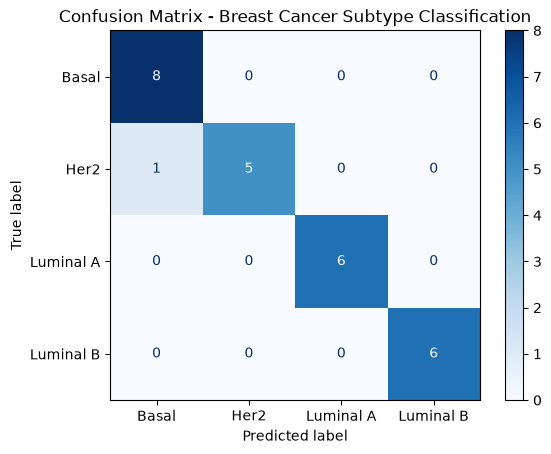

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Breast Cancer Subtype Classification")
plt.show()

In [23]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Gene,Importance
20611,226192_at,0.011932
10094,210735_s_at,0.011449
5922,204162_at,0.008176
4828,202991_at,0.007885
26600,237086_at,0.007134
20134,225687_at,0.007123
20414,225981_at,0.006589
9881,210334_x_at,0.005784
18975,224447_s_at,0.005726
12248,213611_at,0.005551


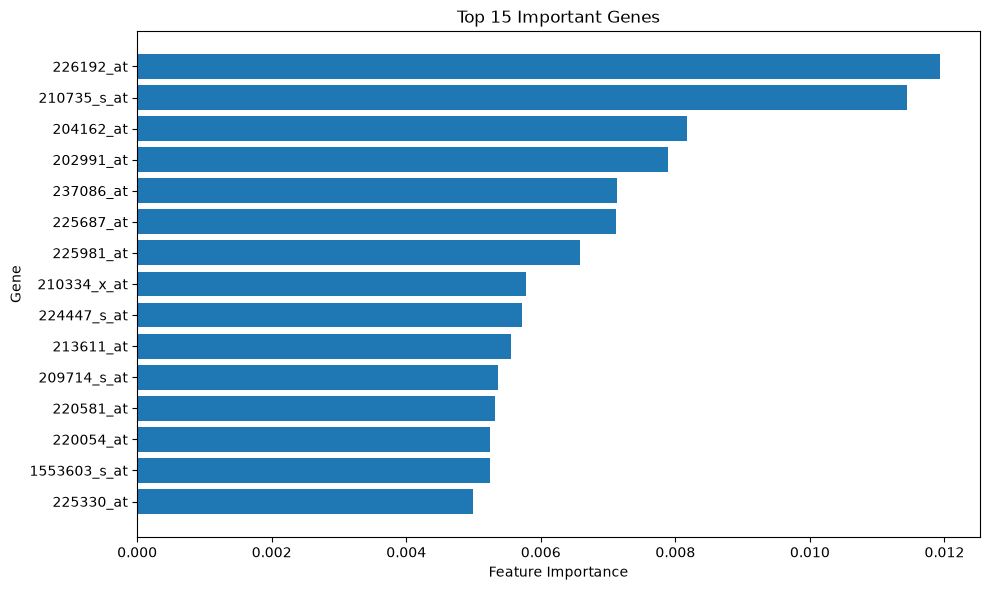

In [24]:
top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Gene"], top15["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Gene")
plt.title("Top 15 Important Genes")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation accuracies:")
print(scores)

print("\nMean Accuracy: {:.2f}%".format(scores.mean() * 100))
print("Standard Deviation: {:.2f}%".format(scores.std() * 100))

Cross-validation accuracies:
[1.         0.96153846 1.         0.92307692 0.80769231]

Mean Accuracy: 93.85%
Standard Deviation: 7.13%


In [26]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=500)

X_selected = selector.fit_transform(X, y)

print("Original number of genes:", X.shape[1])
print("Selected number of genes:", X_selected.shape[1])

Original number of genes: 29873
Selected number of genes: 500


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_selected = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_selected.fit(X_train_sel, y_train_sel)

predictions = rf_selected.predict(X_test_sel)

print("Accuracy with Top 500 Genes: {:.2f}%".format(
    accuracy_score(y_test_sel, predictions) * 100
))

Accuracy with Top 500 Genes: 96.15%


In [28]:
import joblib

joblib.dump(rf_selected, "Models/random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [29]:
selected_genes = X.columns[selector.get_support()]

selected_genes_df = pd.DataFrame({
    "Gene": selected_genes
})

selected_genes_df.to_csv(
    "Results/top500_selected_genes.csv",
    index=False
)

print(selected_genes_df.head())

           Gene
0  1552619_a_at
1    1552733_at
2  1553603_s_at
3  1553613_s_at
4  1554271_a_at


In [30]:
feature_importance.to_csv(
    "Results/feature_importance.csv",
    index=False
)

print("Feature importance saved!")

Feature importance saved!


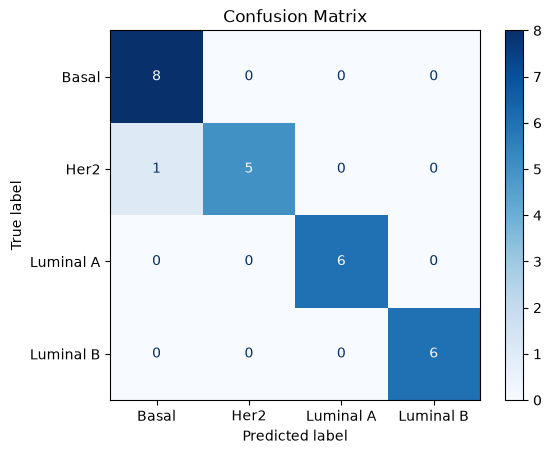

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig(
    "Figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

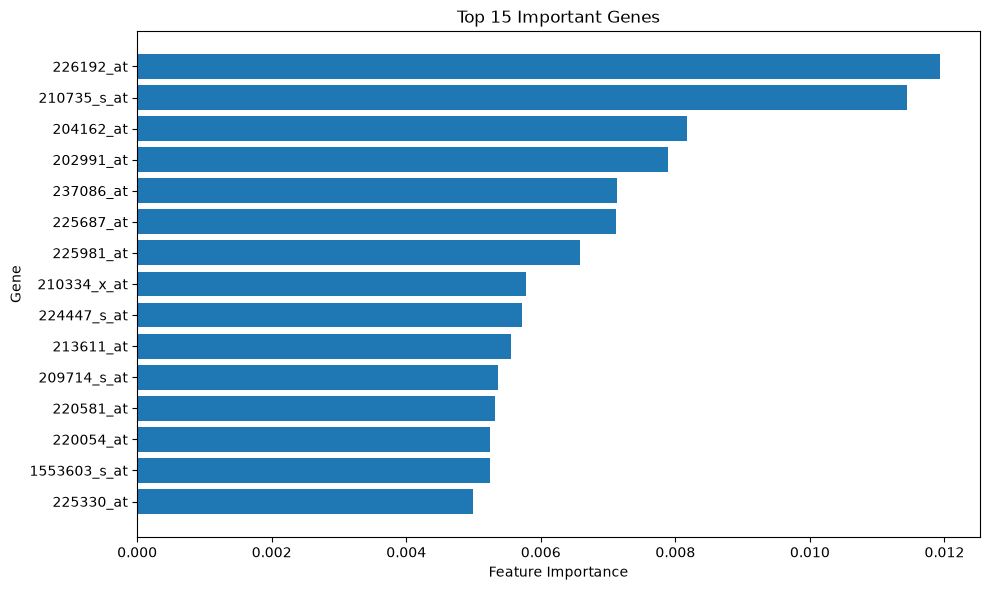

In [32]:
top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Gene"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Gene")
plt.title("Top 15 Important Genes")

plt.tight_layout()

plt.savefig(
    "Figures/top15_genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()